In [ ]:
# install cellpose, matplotlib

In [ ]:
from cellpose import models, io
import os
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
model = models.CellposeModel(gpu=True)

In [17]:
file_name = '../images/Nuclei_no_avg.tif'
file = io.imread(file_name)

masks_pred, flows, styles = model.eval(file)

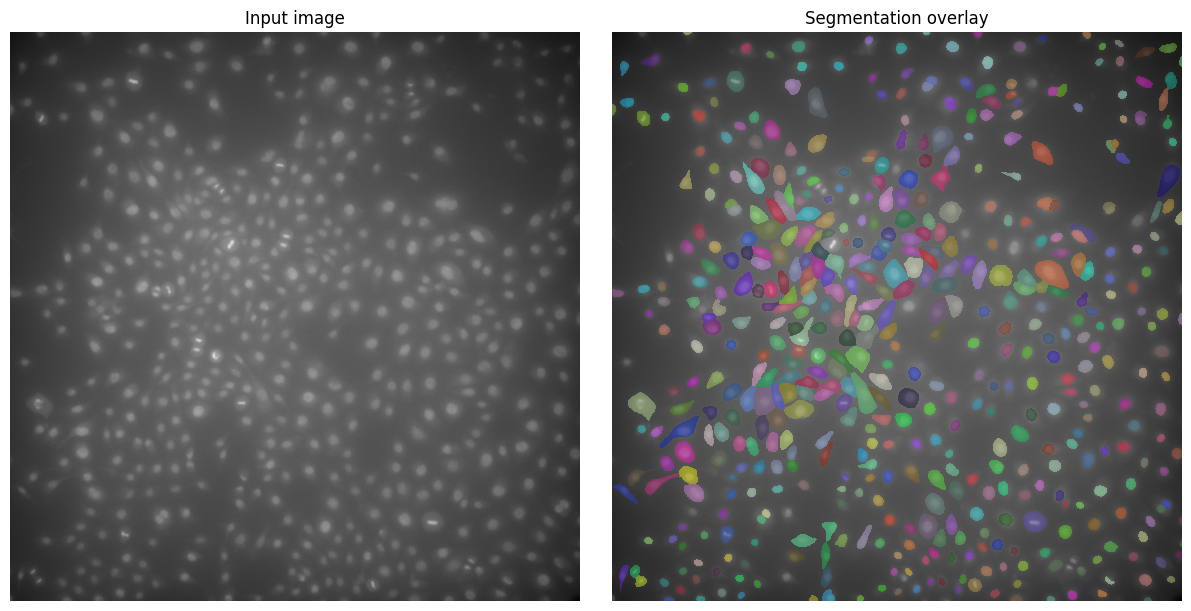

In [18]:
# if masks/flows aren't in the workspace (e.g., cell 1 not executed), compute them
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

axes[0].imshow(file, cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(file, cmap="gray")
n = int(masks_pred.max()) + 1
rng = np.random.default_rng(0)

# random RGBA per label; make background (0) fully transparent
colors = rng.random((n, 4))
colors[:, 3] = 0.45
colors[0, 3] = 0.0
cmap = ListedColormap(colors)

axes[1].imshow(np.ma.masked_equal(masks_pred, 0), cmap=cmap, interpolation="nearest")
axes[1].set_title("Segmentation overlay")
axes[1].axis("off")

plt.show()

In [20]:
# save
io.imsave(f"../images/{os.path.basename(file_name).split('.')[0]}_mask.tif", masks_pred.astype(np.uint16))

In [ ]:
# then open in fiji and use PTBIOP plugin to convert to ROIs (https://github.com/BIOP/ijp-LaRoMe)
# Plugins > BIOP > Image Analysis > ROIs > Label Image to ROIs